<a href="https://colab.research.google.com/github/annonlover/2026-BDA/blob/main/10w_data_vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 31.0 MB/s eta 0:00:00


In [2]:
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

In [3]:
!pip install pydataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 14.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=e8a7ffd9fcccdb5c430f4d3f14b086f0d100bbb38d851d6b1af56cca3e444607
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset


In [5]:
from pydataset import data
iris = data('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [6]:
iris.Species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [7]:
iris.describe()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
iris.Species.value_counts()

,count
Species,
setosa,50
versicolor,50
virginica,50


In [9]:
from IPython.display import display_html
def display_side_by_side(*args):
    """여러 데이터프레임 비교가 쉽게 옆쪽으로 표시한다"""
    html_str=''
    for df in args:
        html_str += df.to_html() + '&nbsp;'*4
    display_html(html_str.replace('table','table style="display:inline"'), raw=True)

In [10]:
from IPython.display import display_html

def display_series_side_by_side(*args, names=None):
    """여러 Series를 옆으로 나란히 표시한다.

    Parameters
    ----------
    *args   : pd.Series 객체들
    names   : 각 Series의 제목 리스트 (생략 시 Series.name 사용)
    """
    html_str = ''
    for i, s in enumerate(args):
        # 제목 결정: names 인자 > Series.name > 인덱스 번호
        if names and i < len(names):
            title = names[i]
        elif s.name is not None:
            title = s.name
        else:
            title = f'Series {i}'

        table_html = s.to_frame(name=title).to_html()
        html_str += table_html + '&nbsp;' * 4

    display_html(
        html_str.replace('table', 'table style="display:inline; vertical-align:top"'),
        raw=True
    )

In [14]:
display_side_by_side(iris.head(), iris.tail())

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
146,6.7,3.0,5.2,2.3,virginica
147,6.3,2.5,5.0,1.9,virginica
148,6.5,3.0,5.2,2.0,virginica
149,6.2,3.4,5.4,2.3,virginica


In [19]:
display_series_side_by_side(
    iris['Petal.Length'][:5],
    iris['Species'].value_counts()
)

,Petal.Length
1,1.4
2,1.4
3,1.3
4,1.5
5,1.4
,count
Species,
setosa,50
versicolor,50
virginica,50


In [ ]:
display_series_side_by_side(iris['Petal.Length'][:5]. iris.Species.value_counts())

In [21]:
import matplotlib.pyplot as plt

[ 4.  5.  7. 16.  9.  5. 13. 14. 10.  6. 10. 16.  7. 11.  4.  2.  4.  1.
  5.  1.]


NameError: name 'bins' is not defined

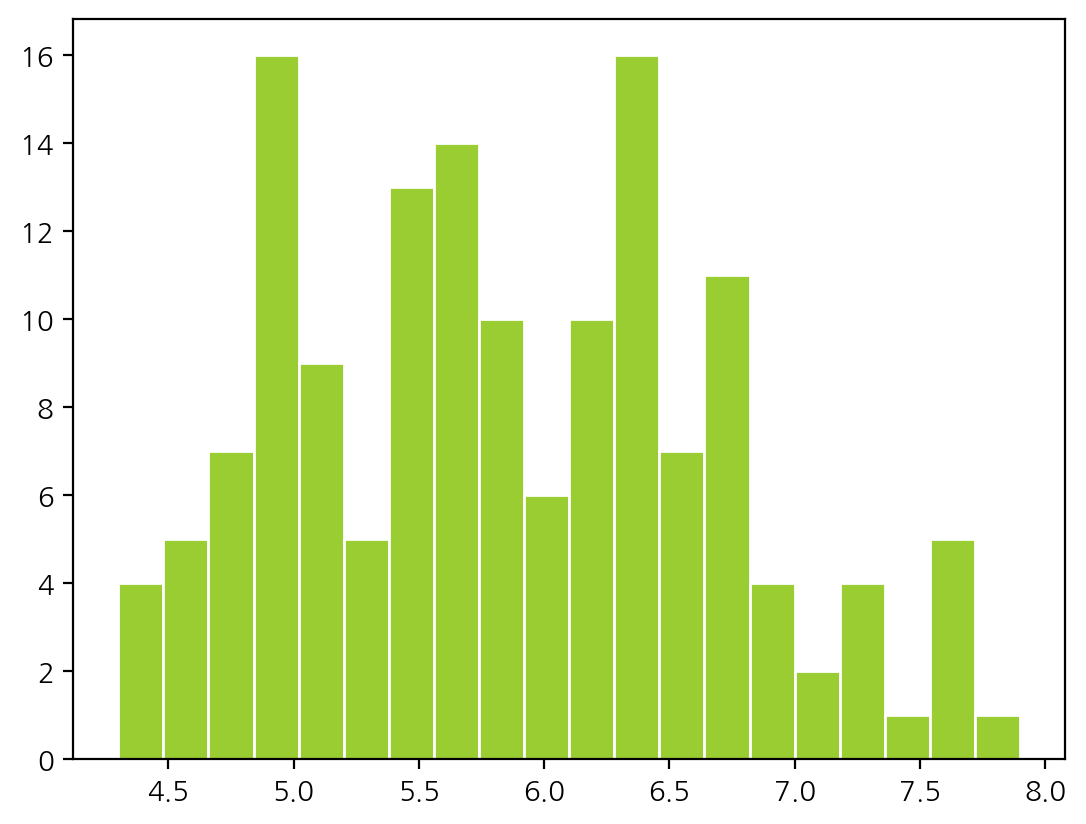

In [22]:
n, bin, patches = plt.hist(iris['Sepal.Length'], bins = 20,
                           color = 'yellowgreen', edgecolor = 'white')

print(n)
print(bins)
print(patches)

/tmp/ipykernel_10428/1158350223.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  patches[i].set_facecolor(cm.get_cmap('viridis')(n[i]/max(n)))


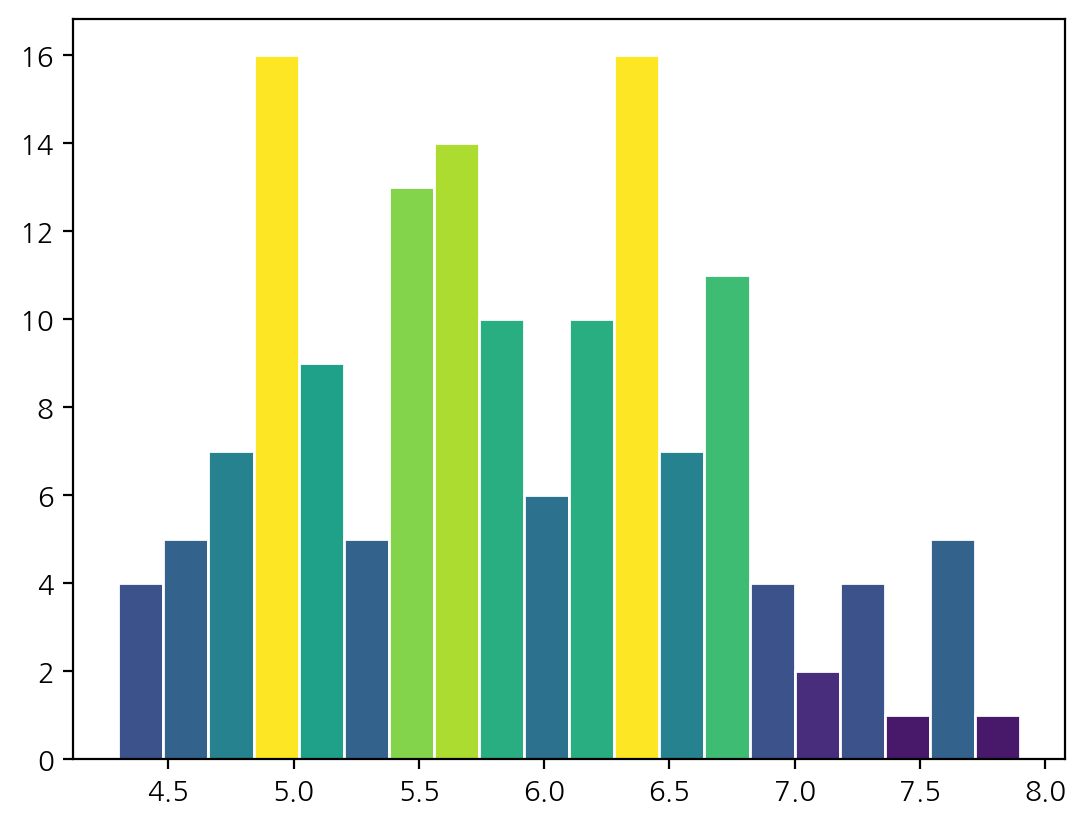

In [24]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

n, bins, patches = plt.hist(
    iris['Sepal.Length'],
    bins=20,
    edgecolor='white'
)

for i in range(len(patches)):
    patches[i].set_facecolor(cm.get_cmap('viridis')(n[i]/max(n)))

plt.show()

In [27]:
import seaborn as sns
sns.histplot(data = iris, x = iris['Sepal.width'], color = 'white')
sns.rugplot(data = iris, x = iris['Sepal.width']);

KeyError: 'Sepal.width'

In [28]:
import seaborn as sns
iris = sns.load_dataset("iris")
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [29]:
pd.set_option('display.precision'.2)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1098726279.py, line 1)

In [30]:
corr = iris[iris.columns[:1].tolist()]

In [34]:
import pandas as pd
pd.set_option('display.precision', 3)
corr_iris = iris[iris.columns[:-1].to_list()].corr()

corr_iris

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


<Axes: >

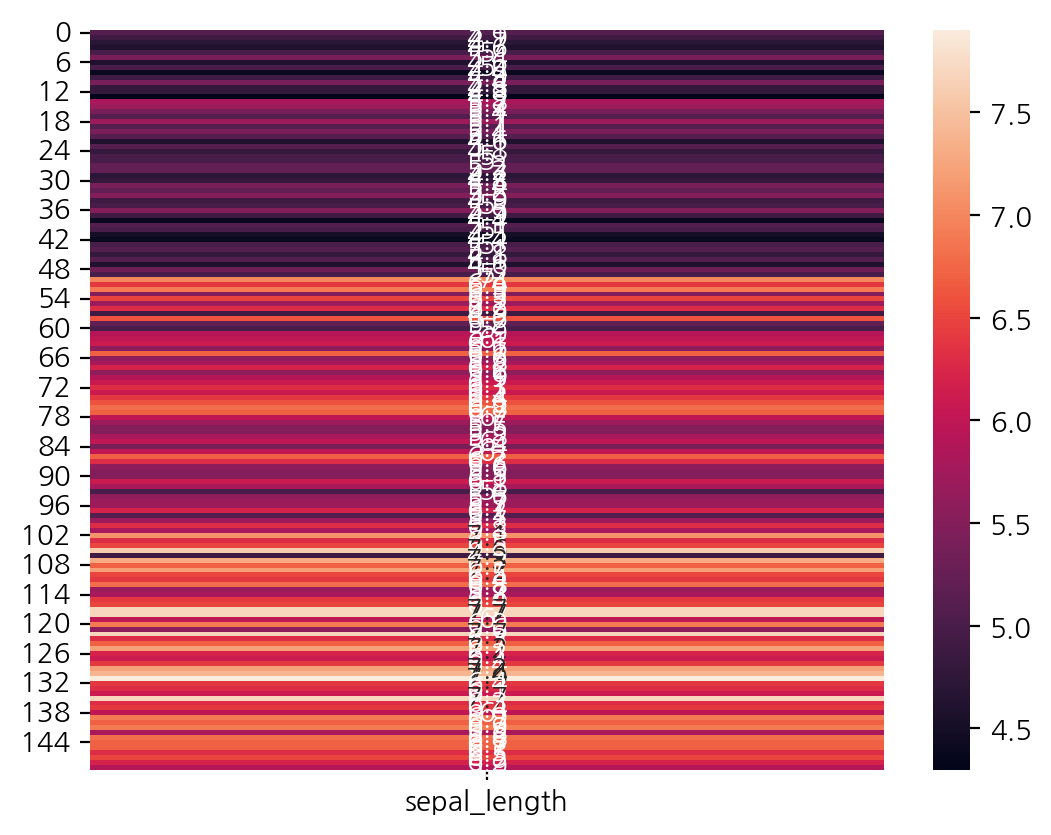

In [35]:
sns.heatmap(corr, annot = True)

In [40]:
mask = np.zero_like(corr)

AttributeError: module 'numpy' has no attribute 'zero_like'

In [39]:
np.triu_indices_from(mask)

NameError: name 'mask' is not defined

In [38]:
import numpy as np

In [41]:
np.triu_indices_from(mask)

NameError: name 'mask' is not defined

In [42]:
mask[np.triu_indices_from(mask)] = True

NameError: name 'mask' is not defined

In [43]:
import numpy as np
mask = np.zeros_like(corr_iris)
mask

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [44]:
np.triu_indices_from(mask)

(array([0, 0, 0, 0, 1, 1, 1, 2, 2, 3]), array([0, 1, 2, 3, 1, 2, 3, 2, 3, 3]))

In [45]:
mask[np.triu_indices_from(mask)] = 1
mask

array([[1., 1., 1., 1.],
       [0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.]])

In [46]:
mask_new = mask[1:, :-1]
mask_new

array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]])

In [47]:
sns.heatmap(corr_iris_new, annot = True, cmap = 'coolwarm', mask = maks_new,
            annot_kws = {"size": 10}, vmin = -1, vmax = 1,
            cbar_kws = {'shrink': .4},
            linewidths = .5);

NameError: name 'corr_iris_new' is not defined

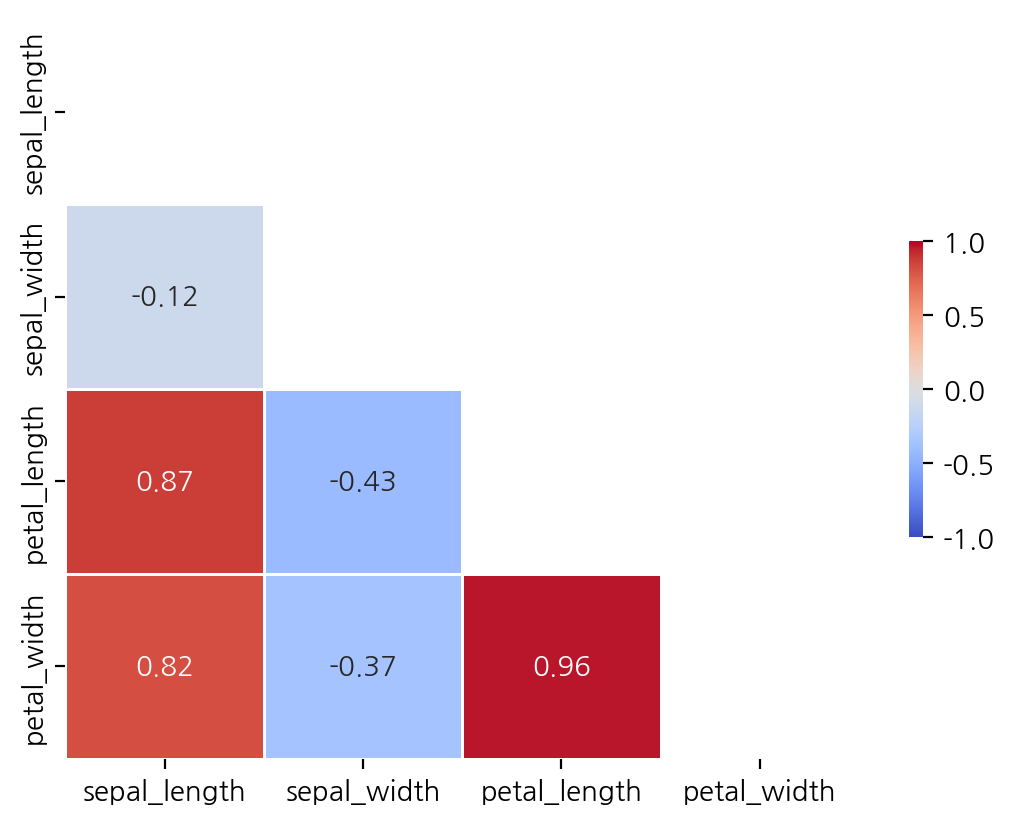

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 상관계수 생성
corr_iris_new = iris.corr(numeric_only=True)

# mask 생성
maks_new = np.triu(np.ones_like(corr_iris_new, dtype=bool))

# heatmap 출력
sns.heatmap(
    corr_iris_new,
    annot=True,
    cmap='coolwarm',
    mask=maks_new,
    annot_kws={'size': 10},
    vmin=-1,
    vmax=1,
    cbar_kws={'shrink': .4},
    linewidths=.5
)

plt.show()

In [ ]:
p = sns.pairplot(iris, hue = "species", palette = "husl", height = 1.4)